# Null calibration for the second-order gap on S²

This notebook demonstrates the second-order null calibration for testing whether the level-2 quadratic features carry information beyond the reduced model.

The target distribution is uniform on `S^2`.  Under equal weights, the usual chi-square calibration works.  Under informative self-normalized importance weights, the naive chi-square calibration is anti-conservative. A quadratic-form calibration restores approximately uniform p-values.

For speed, this notebook uses the local quadratic null approximation for the second-order gap, which is exactly the asymptotic object used by the calibration theorem.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import src

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 160,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})
from scipy.stats import chi2, kstest

In [2]:

rng = np.random.default_rng(20260705)
n = 500
reps_equal = 500
reps_is = 300
proposal_kappa = 1.2
mu = np.array([0.0, 0.0, 1.0])

quad_X, quad_w = src.fibonacci_sphere(20000)
phi_quad = src.features_s2_quadratic_traceless(quad_X)
S = src.covariance_under_quadrature(phi_quad, quad_w)
df = phi_quad.shape[1]

# Equal-weight p-values.
p_equal = []
for b in range(reps_equal):
    X = src.normalize_rows(rng.normal(size=(n, 3)))
    w = np.full(n, 1/n)
    Phi = src.features_s2_quadratic_traceless(X)
    I2 = src.null_gap_quadratic(Phi, w, S)
    p_equal.append(1.0 - chi2.cdf(2*n*I2, df=df))
p_equal = np.array(p_equal)

# Self-normalized importance sampling from a vMF proposal, reweighted to uniform target.
p_is_naive = []
p_is_quad = []
ess_is = []
for b in range(reps_is):
    X = src.sample_vmf_s2(n, mu=mu, kappa=proposal_kappa, rng=rng)
    # Target is uniform, proposal density wrt uniform is proportional to exp(kappa * mu^T x).
    log_raw_w = -proposal_kappa * (X @ mu)
    log_raw_w -= log_raw_w.max()
    w = src.normalize_weights(np.exp(log_raw_w))
    ess_is.append(src.effective_sample_size(w))
    Phi = src.features_s2_quadratic_traceless(X)
    I2 = src.null_gap_quadratic(Phi, w, S)
    p_is_naive.append(1.0 - chi2.cdf(2*n*I2, df=df))

    Sigma_hat = src.moment_covariance_self_normalized_is(Phi, w, null_mean=np.zeros(df))
    omegas = src.quadratic_form_omegas(S, Sigma_hat)
    p_is_quad.append(src.weighted_chisq_pvalue(n * I2, omegas, rng=rng, num_sim=8000))

p_is_naive = np.array(p_is_naive)
p_is_quad = np.array(p_is_quad)
ess_is = np.array(ess_is)

summary = pd.DataFrame([
    {"Sampling": "Equal", "Calibration": "chi-square", "ESS": n,
     "p10": np.quantile(p_equal, .10), "p50": np.quantile(p_equal, .50),
     "p90": np.quantile(p_equal, .90), "Size at .05": np.mean(p_equal < .05),
     "KS": kstest(p_equal, "uniform").statistic},
    {"Sampling": "Importance", "Calibration": "naive chi-square", "ESS": ess_is.mean(),
     "p10": np.quantile(p_is_naive, .10), "p50": np.quantile(p_is_naive, .50),
     "p90": np.quantile(p_is_naive, .90), "Size at .05": np.mean(p_is_naive < .05),
     "KS": kstest(p_is_naive, "uniform").statistic},
    {"Sampling": "Importance", "Calibration": "quadratic form", "ESS": ess_is.mean(),
     "p10": np.quantile(p_is_quad, .10), "p50": np.quantile(p_is_quad, .50),
     "p90": np.quantile(p_is_quad, .90), "Size at .05": np.mean(p_is_quad < .05),
     "KS": kstest(p_is_quad, "uniform").statistic},
])
summary.round(3)


,Sampling,Calibration,ESS,p10,p50,p90,Size at .05,KS
0,Equal,chi-square,500.000,0.135,0.508,0.897,0.040,0.044
1,Importance,naive chi-square,316.506,0.008,0.261,0.764,0.200,0.254
2,Importance,quadratic form,316.506,0.076,0.530,0.896,0.067,0.057


Correctly calibrated p-values should be approximately Uniform(0,1).  The importance-weighted sample has lower effective sample size, and the naive chi-square calibration is anti-conservative because it ignores the sampling covariance induced by the weights.

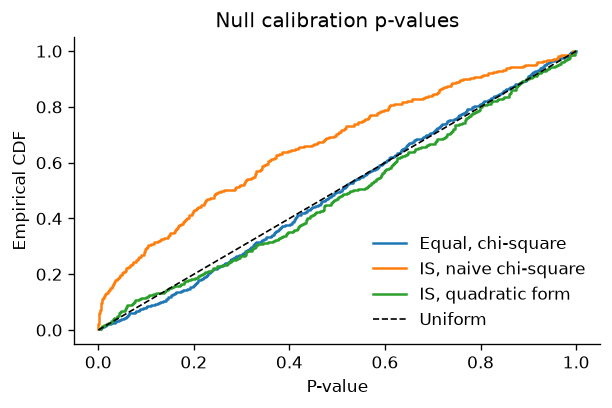

In [3]:

def ecdf(vals):
    vals = np.sort(vals)
    y = np.arange(1, len(vals)+1) / len(vals)
    return vals, y

fig, ax = plt.subplots(figsize=(5.2, 3.5))
for vals, label in [
    (p_equal, "Equal, chi-square"),
    (p_is_naive, "IS, naive chi-square"),
    (p_is_quad, "IS, quadratic form"),
]:
    x, y = ecdf(vals)
    ax.step(x, y, where="post", label=label)
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Uniform")
ax.set_xlabel("P-value")
ax.set_ylabel("Empirical CDF")
ax.set_title("Null calibration p-values")
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
plt.show()
